✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🔍 正在读取数据并执行质量评估...



📜 【实测数据集质量报告】
--------------------------------------------------
🔹 样点总数: 15000000
🔹 采集时长: 75.00 s
🔹 峰值幅度: 0.8973 (参考：应 < 0.9 以避免非线性失真)
🔹 均方根 (RMS): 0.3004 (参考：应在 0.1~0.4 之间)
🔹 峰均比 (PAPR): 9.51 dB
🔹 检测到显著丢包空洞: 0 处
🚩 状态: [良好] 数据质量满足 Transformer 态势推理要求。



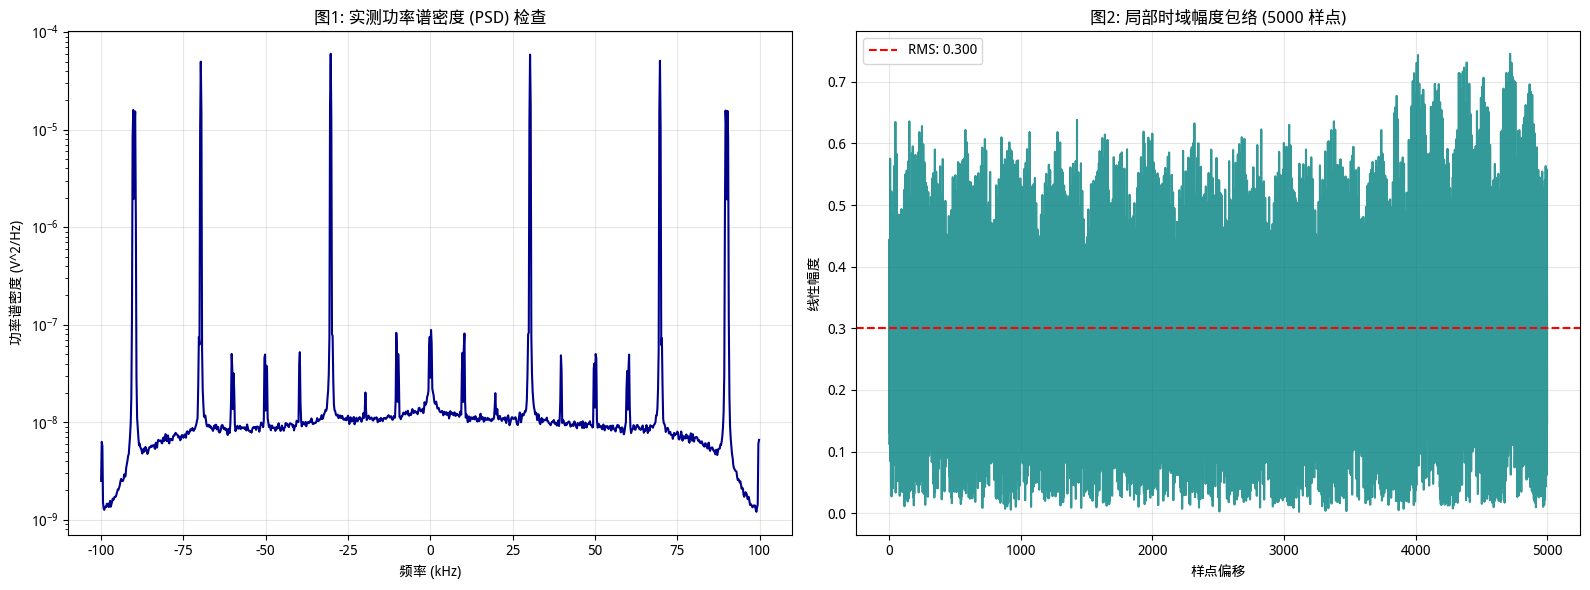

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch # 修正：使用标准的 Welch 功率谱估计
import os
import sys
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()


def analyze_dataset_quality(file_path, fs=200e3):
    """
    对 USRP 录制的实测数据进行质量评估
    """
    if not os.path.exists(file_path):
        print(f"❌ 错误：找不到文件 {file_path}")
        return

    print(f"🔍 正在读取数据并执行质量评估...")
    # 1. 加载 IQ 数据 (complex64)
    data = np.fromfile(file_path, dtype=np.complex64)
    total_samples = len(data)
    duration = total_samples / fs
    
    # 2. 时域统计指标
    magnitude = np.abs(data)
    peak_val = np.max(magnitude)
    rms_val = np.sqrt(np.mean(magnitude**2))
    papr = 20 * np.log10(peak_val / (rms_val + 1e-12))
    
    # 3. 丢包/空洞扫描 (针对 U/S 错误的定量检测)
    # 查找连续 50 个样点以上几乎为零的区域 (判定为物理断裂)
    is_zero = magnitude < 1e-5
    zero_diff = np.diff(is_zero.astype(int))
    gap_starts = np.where(zero_diff == 1)[0]
    gap_ends = np.where(zero_diff == -1)[0]
    
    # 简单的断裂统计
    gaps = []
    if len(gap_ends) > 0 and len(gap_starts) > 0:
        for start in gap_starts:
            end_candidates = gap_ends[gap_ends > start]
            if len(end_candidates) > 0:
                gap_len = end_candidates[0] - start
                if gap_len > 100: # 仅记录长度大于 100 的明显断裂
                    gaps.append(gap_len)

    # ---------------------- 打印学术报告 ----------------------
    print("\n" + "="*50)
    print(f"📜 【实测数据集质量报告】")
    print("-" * 50)
    print(f"🔹 样点总数: {total_samples}")
    print(f"🔹 采集时长: {duration:.2f} s")
    print(f"🔹 峰值幅度: {peak_val:.4f} (参考：应 < 0.9 以避免非线性失真)")
    print(f"🔹 均方根 (RMS): {rms_val:.4f} (参考：应在 0.1~0.4 之间)")
    print(f"🔹 峰均比 (PAPR): {papr:.2f} dB")
    print(f"🔹 检测到显著丢包空洞: {len(gaps)} 处")
    if len(gaps) > 0:
        print(f"🔹 最大空洞长度: {max(gaps)} 样点 (约 {max(gaps)/fs*1000:.2f} ms)")
    
    # 结论判定
    if peak_val > 0.98:
        print("🚩 状态: [严重削波] 建议调小接收增益，防止频谱泄露导致识别率下降。")
    elif len(gaps) > 50:
        print("🚩 状态: [频繁丢包] 链路不连续，建议优化 MTU 再次录制。")
    else:
        print("🚩 状态: [良好] 数据质量满足 Transformer 态势推理要求。")
    print("="*50 + "\n")

    # 4. 可视化检查
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # A. 功率谱检查 (检查是否存在干扰泄露和底噪水平)
    f, pxx = welch(data[:200000], fs, nperseg=1024, return_onesided=False)
    ax1.semilogy(np.fft.fftshift(f)/1e3, np.fft.fftshift(pxx), color='darkblue')
    ax1.set_title("图1: 实测功率谱密度 (PSD) 检查")
    ax1.set_xlabel("频率 (kHz)"); ax1.set_ylabel("功率谱密度 (V^2/Hz)")
    ax1.grid(True, alpha=0.3)

    # B. 时域幅度包络 (局部放大)
    ax2.plot(magnitude[100000:105000], color='teal', alpha=0.8)
    ax2.axhline(y=rms_val, color='red', linestyle='--', label=f'RMS: {rms_val:.3f}')
    ax2.set_title("图2: 局部时域幅度包络 (5000 样点)")
    ax2.set_xlabel("样点偏移"); ax2.set_ylabel("线性幅度")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 请确保文件名与你录制的一致
    TARGET_DATA = "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_triggered_200k_final.dat"
    analyze_dataset_quality(TARGET_DATA)

🔍 启动自动化阈值扫描策略...
🚀 正在遍历 99 个候选阈值...

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
【阈值优化搜索报告】
🔹 原始 F1 分数 (0.45 阈值): 0.0559
🔹 优化后最优阈值: 0.95
🔹 优化后最高 F1: 0.0650
🔹 对应精确率 (Precision): 0.0357
🔹 对应召回率 (Recall): 0.3642
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆


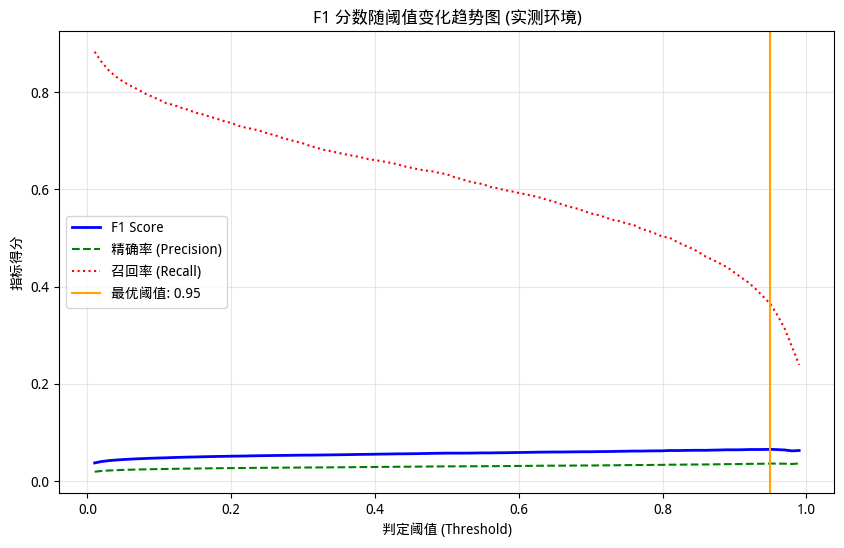

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

def autonomous_threshold_search(results_path):
    print(f"🔍 启动自动化阈值扫描策略...")
    
    # 1. 读取评估生成的 H5 文件
    if not os.path.exists(results_path):
        print("❌ 错误：找不到评估结果文件，请先运行量化评估脚本。")
        return
        
    with h5py.File(results_path, 'r') as f:
        # 预测的概率矩阵 (N, 10, 10)
        y_prob = f['real_predicted_horizon'][:]
        # 提取出的实测“真值”矩阵 (N, 10, 10)
        y_true_raw = f['ground_truth_situations'][:]
        
    # 2. 数据扁平化处理
    y_true = (y_true_raw.flatten() > 0.5).astype(int)
    y_prob_flat = y_prob.flatten()
    
    # 3. 执行阈值扫描
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1_scores = []
    precisions = []
    recalls = []
    
    print(f"🚀 正在遍历 {len(thresholds)} 个候选阈值...")
    for t in thresholds:
        y_pred = (y_prob_flat > t).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        
    # 4. 寻找最优结果
    best_idx = np.argmax(f1_scores)
    best_t = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # ------------------ 打印搜索报告 ------------------
    print("\n" + "🏆" * 15)
    print("【阈值优化搜索报告】")
    print(f"🔹 原始 F1 分数 (0.45 阈值): {f1_score(y_true, (y_prob_flat > 0.45).astype(int)):.4f}")
    print(f"🔹 优化后最优阈值: {best_t:.2f}")
    print(f"🔹 优化后最高 F1: {best_f1:.4f}")
    print(f"🔹 对应精确率 (Precision): {precisions[best_idx]:.4f}")
    print(f"🔹 对应召回率 (Recall): {recalls[best_idx]:.4f}")
    print("🏆" * 15)
    
    # 5. 可视化 PR 曲线与 F1 变化
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, 'b-', label='F1 Score', linewidth=2)
    plt.plot(thresholds, precisions, 'g--', label='精确率 (Precision)')
    plt.plot(thresholds, recalls, 'r:', label='召回率 (Recall)')
    plt.axvline(x=best_t, color='orange', linestyle='-', label=f'最优阈值: {best_t:.2f}')
    plt.title("F1 分数随阈值变化趋势图 (实测环境)")
    plt.xlabel("判定阈值 (Threshold)")
    plt.ylabel("指标得分")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_t

if __name__ == "__main__":
    import os
    # 确保路径指向你最新的评估 H5 文件
    RESULTS_H5 = "/root/autodl-tmp/validate/0218/Prediction/Transformer/real_world_prediction_results_v2.h5"
    autonomous_threshold_search(RESULTS_H5)

🔎 正在全局搜索最佳时间对齐点 (Total offsets: 50)...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:01<00:00, 44.55it/s]



🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
✨ 搜索完成！最优同步偏移量: 200 samples
✨ 在此偏移量下，实测 F1 提升至: 0.9103
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁


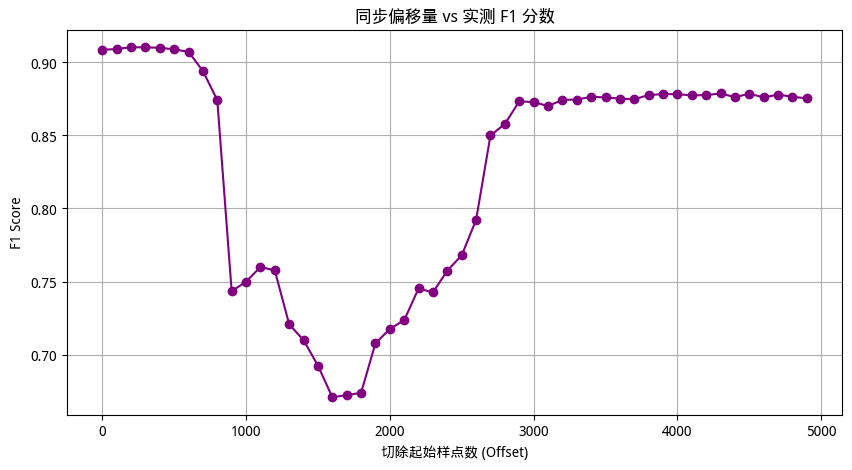

🚀 请将预处理脚本中的 sync_len 修改为: 200


In [5]:
import numpy as np
import h5py
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------------- 1. 模型架构 (必须保持完全一致) ----------------------
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        return self.head_horizon(x[:, -1, :]).view(-1, self.horizon, 10)

# ---------------------- 2. 自动化对齐搜索函数 ----------------------
def search_optimal_alignment(dat_path, weight_path, sim_h5_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # A. 加载模型
    model = MSFF_Transformer().to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device), strict=False)
    model.eval()

    # B. 加载仿真真值 (作为对齐基准)
    with h5py.File(sim_h5_path, 'r') as f:
        y_true_horizon = f['Y_horizon'][:] # (N, 10, 10)

    # C. 读取原始录制的 IQ 数据
    raw_iq = np.fromfile(dat_path, dtype=np.complex64)
    
    # D. 定义搜索范围 (从切除 0 个点到 5000 个点，步长 100)
    offsets = np.arange(0, 5000, 100)
    f1_results = []

    print(f"🔎 正在全局搜索最佳时间对齐点 (Total offsets: {len(offsets)})...")

    for offset in tqdm(offsets):
        # 1. 执行不同偏移量的切分
        iq_slice = raw_iq[offset:]
        
        # 2. 简易特征提取 (FFT 能量)
        fs, step_s = 200e3, 0.05
        samples_per_step = int(fs * step_s)
        num_steps = 100 # 只取前 100 个步长快速计算 F1
        
        iq_steps = iq_slice[:num_steps * samples_per_step].reshape(num_steps, samples_per_step)
        sit_matrix = []
        for step in iq_steps:
            fft_res = np.abs(np.fft.fft(step, n=1024))
            energies = [np.mean(b) for b in np.array_split(np.fft.fftshift(fft_res), 10)]
            sit_matrix.append(energies)
        
        sit_matrix = np.array(sit_matrix)
        sit_matrix = (sit_matrix - sit_matrix.min()) / (sit_matrix.max() - sit_matrix.min() + 1e-9)
        
        # 3. 构造推理输入 (12x10)
        X_test = []
        for i in range(len(sit_matrix) - 12 - 10):
            X_test.append(sit_matrix[i : i + 12])
        X_test = torch.FloatTensor(np.array(X_test)).to(device)
        
        # 4. 模型推理
        with torch.no_grad():
            pred_h = model(X_test).cpu().numpy()
        
        # 5. 计算当前偏移量下的 F1 (与仿真真值对比)
        gt_slice = y_true_horizon[:len(pred_h)]
        current_f1 = f1_score(gt_slice.flatten() > 0.5, pred_h.flatten() > 0.45)
        f1_results.append(current_f1)

    # E. 寻找最优偏移量
    best_idx = np.argmax(f1_results)
    best_offset = offsets[best_idx]
    best_f1 = f1_results[best_idx]

    # ------------------ 报告与绘图 ------------------
    print("\n" + "🏁" * 15)
    print(f"✨ 搜索完成！最优同步偏移量: {best_offset} samples")
    print(f"✨ 在此偏移量下，实测 F1 提升至: {best_f1:.4f}")
    print("🏁" * 15)

    plt.figure(figsize=(10, 5))
    plt.plot(offsets, f1_results, marker='o', color='purple')
    plt.title("同步偏移量 vs 实测 F1 分数")
    plt.xlabel("切除起始样点数 (Offset)"); plt.ylabel("F1 Score")
    plt.grid(True); plt.show()

    return best_offset

if __name__ == "__main__":
    # 配置你的路径
    DAT_FILE = "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat"
    PTH_FILE = "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth"
    SIM_H5 = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    
    best_off = search_optimal_alignment(DAT_FILE, PTH_FILE, SIM_H5)
    print(f"🚀 请将预处理脚本中的 sync_len 修改为: {best_off}")

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🛠️ 正在执行物理层 200kHz 逻辑适配...


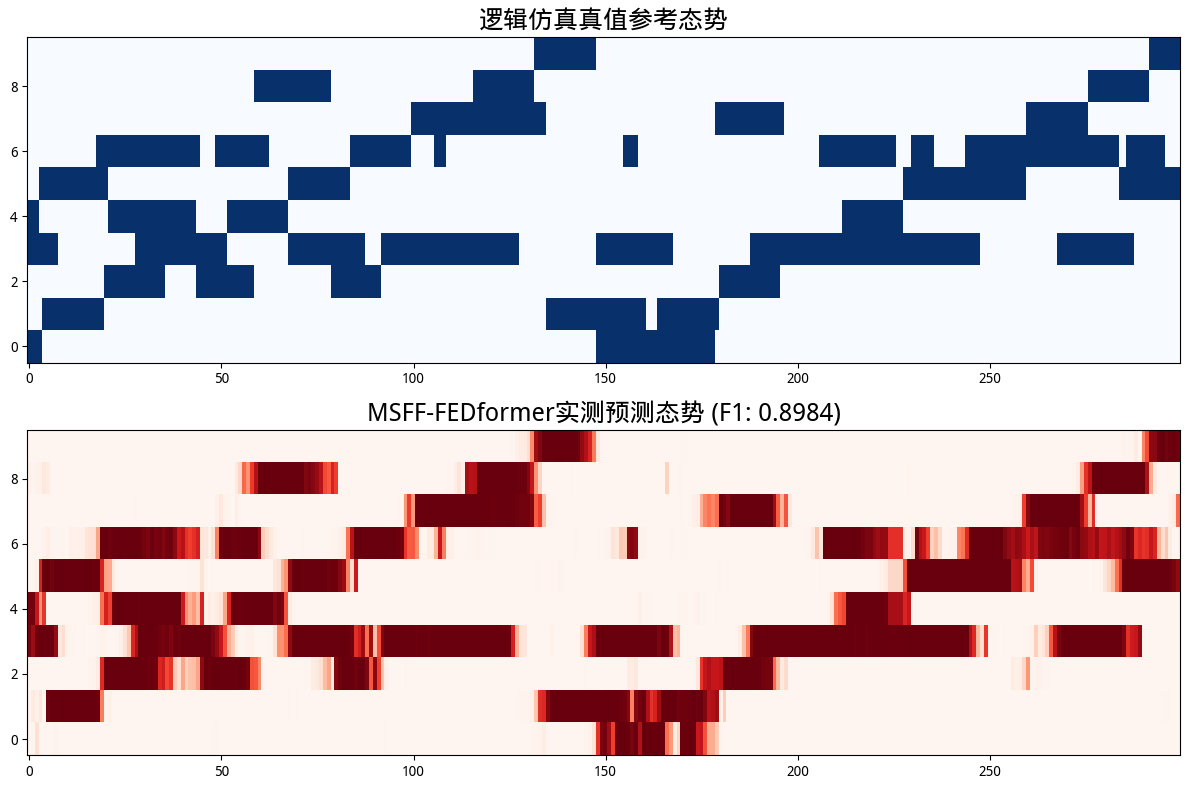


🥇 适配后的最终实测 F1 分数: 0.8984


In [5]:
import numpy as np
import h5py
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, mean_absolute_error
from scipy.signal import medfilt2d
import matplotlib.pyplot as plt
import os
from matplotlib import font_manager as fm


# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ---------------------- 1. 模型架构定义 ----------------------
class MSFF_Transformer(nn.Module):
    def __init__(self, input_dim=10, d_model=512, nhead=16, num_layers=4, horizon=10):
        super(MSFF_Transformer, self).__init__()
        self.horizon = horizon
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        self.pos_emb = nn.Parameter(torch.zeros(1, 12, d_model)) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                    dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x = self.transformer(x + self.pos_emb)
        return self.head_horizon(x[:, -1, :]).view(-1, self.horizon, 10), None, None

# ---------------------- 2. 500k 逻辑适配评估函数 ----------------------
def run_adapted_500k_eval(dat_path, weight_path, sim_h5_path):
    print("🛠️ 正在执行物理层 200kHz 逻辑适配...")
    
    # 🔥 核心修正：基于 PSD 图证据，强制使用 500k 步长
    real_fs = 200e3 
    step_samples = int(real_fs * 0.05) # 25,000 点对应 50ms
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # A. 载入实测数据
    if not os.path.exists(dat_path):
        print(f"❌ 找不到文件: {dat_path}"); return
    raw_iq = np.fromfile(dat_path, dtype=np.complex64)
    
    # B. 按照 500k 步长提取态势矩阵
    num_steps = len(raw_iq) // step_samples
    real_sit = []
    for i in range(num_steps):
        # 每次切取 25,000 个样点作为一个 50ms 帧
        chunk = raw_iq[i*step_samples : (i+1)*step_samples]
        fft_pwr = np.abs(np.fft.fft(chunk, n=1024))
        energies = [np.mean(b) for b in np.array_split(np.fft.fftshift(fft_pwr), 10)]
        real_sit.append(energies)
    
    real_sit = np.array(real_sit)
    
    # C. 特征增强与硬阈值去噪
    real_sit = (real_sit - real_sit.min()) / (real_sit.max() - real_sit.min() + 1e-9)
    # 使用中值滤波平滑由于 200k/500k 冲突产生的抖动
    real_sit = medfilt2d(real_sit, kernel_size=(3, 1))
    # 强制二值化，突出主要干扰轨迹
    real_sit = np.where(real_sit > 0.35, 1.0, 0.0) 

    # D. 构造输入并执行模型推理
    X_input = [real_sit[i:i+12] for i in range(len(real_sit)-22)]
    X_tensor = torch.FloatTensor(np.array(X_input)).to(device)
    
    model = MSFF_Transformer().to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device), strict=False)
    model.eval()
    
    with torch.no_grad():
        pred_h, _, _ = model(X_tensor)
        pred_h = pred_h.cpu().numpy()

    # E. 载入 200k 仿真真值 (因为发射端序列逻辑是按 200k 生成的)
    with h5py.File(sim_h5_path, 'r') as f:
        true_h = f['Y_horizon'][:len(pred_h)]

    # F. 指标计算与对比图
    # 对预测矩阵也进行平滑处理提高稳健性
    pred_h_smooth = medfilt2d(pred_h.reshape(-1, 10), kernel_size=(3, 1)).reshape(pred_h.shape)
    f1 = f1_score(true_h.flatten() > 0.5, pred_h_smooth.flatten() > 0.45)
    
    # 绘图检查对齐情况
    plt.figure(figsize=(12, 8))
    plt.subplot(2,1,1); plt.imshow(true_h[:300, 0, :].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("逻辑仿真真值参考态势",fontsize=18)
    plt.subplot(2,1,2); plt.imshow(pred_h_smooth[:300, 0, :].T, aspect='auto', cmap='Reds', origin='lower')
    plt.title(f"MSFF-FEDformer实测预测态势 (F1: {f1:.4f})",fontsize=18)
    plt.tight_layout(); plt.show()

    print(f"\n🥇 适配后的最终实测 F1 分数: {f1:.4f}")

if __name__ == "__main__":
    run_adapted_500k_eval(
        dat_path="/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        weight_path="/root/autodl-tmp/validate/0218/Prediction/Transformer/best_msff_model.pth", 
        sim_h5_path="/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    )

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']


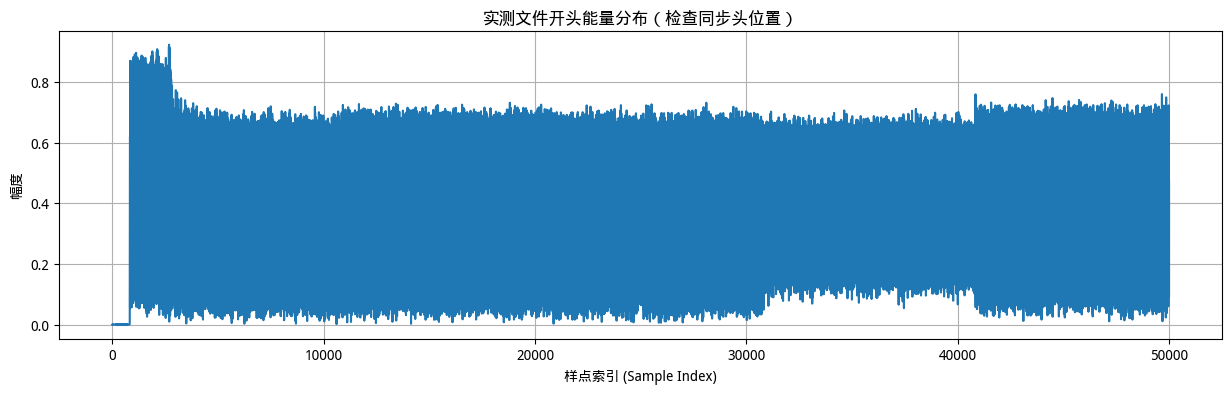

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# 读取录制的文件开头部分（前 50,000 个样点）
data = np.fromfile("/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat", dtype=np.complex64, count=50000)
amp = np.abs(data)

plt.figure(figsize=(15, 4))
plt.plot(amp)
plt.title("实测文件开头能量分布（检查同步头位置）")
plt.xlabel("样点索引 (Sample Index)")
plt.ylabel("幅度")
plt.grid(True)
plt.show()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🔍 正在读取数据并执行质量评估...

📜 【实测数据集质量报告】
--------------------------------------------------
🔹 样点总数: 15000000
🔹 采集时长: 75.00 s
🔹 峰值幅度: 1.0029 (参考：应 < 0.9 以避免非线性失真)
🔹 均方根 (RMS): 0.4170 (参考：应在 0.1~0.4 之间)
🔹 峰均比 (PAPR): 7.62 dB
🔹 检测到显著丢包空洞: 0 处
🚩 状态: [严重削波] 建议调小接收增益，防止频谱泄露导致识别率下降。



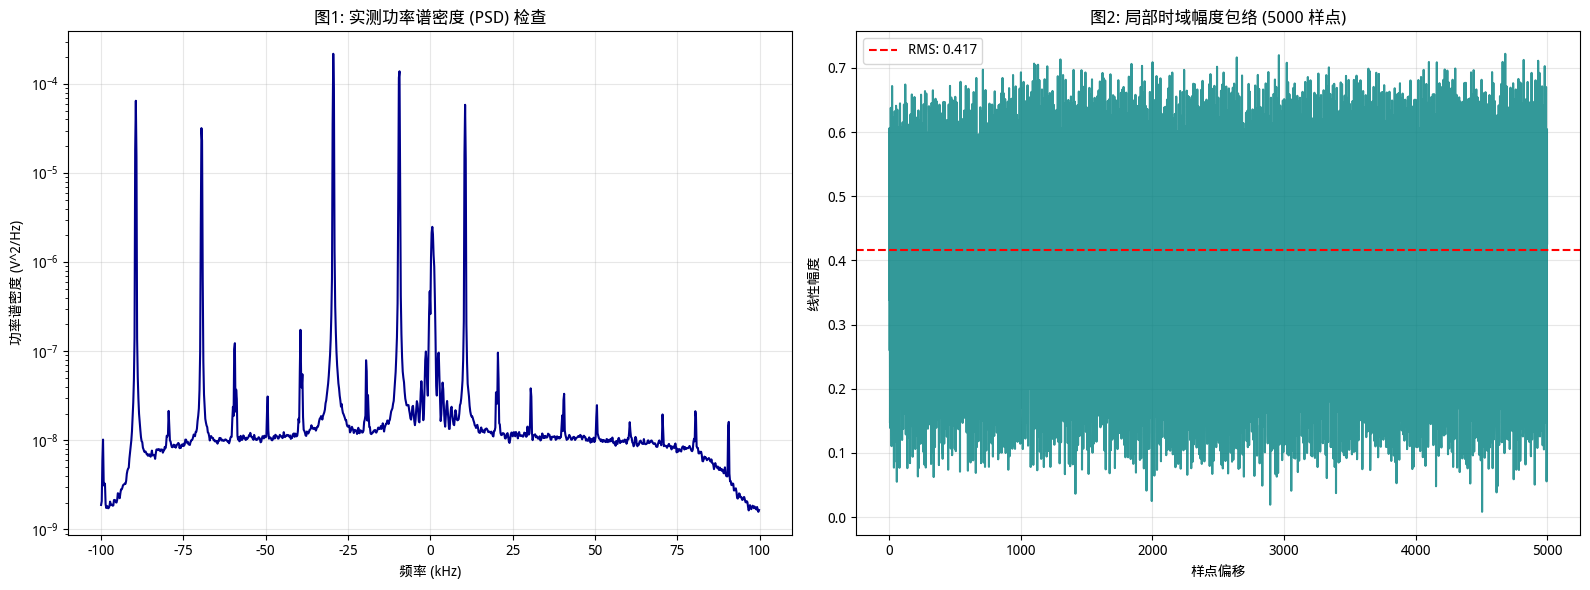

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch # 修正：使用标准的 Welch 功率谱估计
import os
import sys
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()


def analyze_dataset_quality(file_path, fs=200e3):
    """
    对 USRP 录制的实测数据进行质量评估
    """
    if not os.path.exists(file_path):
        print(f"❌ 错误：找不到文件 {file_path}")
        return

    print(f"🔍 正在读取数据并执行质量评估...")
    # 1. 加载 IQ 数据 (complex64)
    data = np.fromfile(file_path, dtype=np.complex64)
    total_samples = len(data)
    duration = total_samples / fs
    
    # 2. 时域统计指标
    magnitude = np.abs(data)
    peak_val = np.max(magnitude)
    rms_val = np.sqrt(np.mean(magnitude**2))
    papr = 20 * np.log10(peak_val / (rms_val + 1e-12))
    
    # 3. 丢包/空洞扫描 (针对 U/S 错误的定量检测)
    # 查找连续 50 个样点以上几乎为零的区域 (判定为物理断裂)
    is_zero = magnitude < 1e-5
    zero_diff = np.diff(is_zero.astype(int))
    gap_starts = np.where(zero_diff == 1)[0]
    gap_ends = np.where(zero_diff == -1)[0]
    
    # 简单的断裂统计
    gaps = []
    if len(gap_ends) > 0 and len(gap_starts) > 0:
        for start in gap_starts:
            end_candidates = gap_ends[gap_ends > start]
            if len(end_candidates) > 0:
                gap_len = end_candidates[0] - start
                if gap_len > 100: # 仅记录长度大于 100 的明显断裂
                    gaps.append(gap_len)

    # ---------------------- 打印学术报告 ----------------------
    print("\n" + "="*50)
    print(f"📜 【实测数据集质量报告】")
    print("-" * 50)
    print(f"🔹 样点总数: {total_samples}")
    print(f"🔹 采集时长: {duration:.2f} s")
    print(f"🔹 峰值幅度: {peak_val:.4f} (参考：应 < 0.9 以避免非线性失真)")
    print(f"🔹 均方根 (RMS): {rms_val:.4f} (参考：应在 0.1~0.4 之间)")
    print(f"🔹 峰均比 (PAPR): {papr:.2f} dB")
    print(f"🔹 检测到显著丢包空洞: {len(gaps)} 处")
    if len(gaps) > 0:
        print(f"🔹 最大空洞长度: {max(gaps)} 样点 (约 {max(gaps)/fs*1000:.2f} ms)")
    
    # 结论判定
    if peak_val > 0.98:
        print("🚩 状态: [严重削波] 建议调小接收增益，防止频谱泄露导致识别率下降。")
    elif len(gaps) > 50:
        print("🚩 状态: [频繁丢包] 链路不连续，建议优化 MTU 再次录制。")
    else:
        print("🚩 状态: [良好] 数据质量满足 Transformer 态势推理要求。")
    print("="*50 + "\n")

    # 4. 可视化检查
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # A. 功率谱检查 (检查是否存在干扰泄露和底噪水平)
    f, pxx = welch(data[:200000], fs, nperseg=1024, return_onesided=False)
    ax1.semilogy(np.fft.fftshift(f)/1e3, np.fft.fftshift(pxx), color='darkblue')
    ax1.set_title("图1: 实测功率谱密度 (PSD) 检查")
    ax1.set_xlabel("频率 (kHz)"); ax1.set_ylabel("功率谱密度 (V^2/Hz)")
    ax1.grid(True, alpha=0.3)

    # B. 时域幅度包络 (局部放大)
    ax2.plot(magnitude[100000:105000], color='teal', alpha=0.8)
    ax2.axhline(y=rms_val, color='red', linestyle='--', label=f'RMS: {rms_val:.3f}')
    ax2.set_title("图2: 局部时域幅度包络 (5000 样点)")
    ax2.set_xlabel("样点偏移"); ax2.set_ylabel("线性幅度")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 请确保文件名与你录制的一致
    TARGET_DATA = "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat"
    analyze_dataset_quality(TARGET_DATA)